# First Things First

Before using this journal, make sure your python environment has manim and numpy installed:

If not, uncomment the following code block and run it.

In [ ]:
#%% pip install manim
#%% pip install numpy

In [3]:
import manim as mn
from manim import *
from manim.typing import Vector3D
from manim.typing import Vector3DLike
from manim.typing import Vector2D
from manim.typing import Vector2DLike
import numpy as np


In [4]:
config.media_width = "80%"
config.verbosity = "WARNING"

print(mn.__version__)

0.20.1


# Component

In [6]:
class Component(VMobject):
    def __init__(
            self,
            center = ORIGIN,
            radius = 1.0,
            **kwargs
    ) -> None:
        self.center = center

        # TODO: Make calculation to find true radius of item...maybe have that be defined by the child class
        self.radius = radius

        super().__init__(**kwargs)

In [7]:
class Connection(Dot):
    def __init__(self, point=ORIGIN, radius=0.08, **kwargs):
        super().__init__(point, radius, **kwargs)

# Component1

In [134]:
class Component1(Component):
    def __init__(
            self,
            center: Vector3D = ORIGIN,
            conn: Vector3D = 0.5*UP,
            initial_rot = 0.0,
            **kwargs
    ) -> None:
        self.mcenter = center
        self.conn = Connection(self.mcenter+conn, color=RED)
        
        super().__init__(**kwargs)
    
    def get_conn(self) -> Connection | Vector3D:
        return self.conn

    def get_center(self) -> Connection | Vector3D:
        return self.mcenter
    
    def rotate(self, theta: float, **kwargs):
        self.conn.rotate(theta, about_point=self.get_center())
        super().rotate(theta, **kwargs)
        return self

    def shift(self, *vectors: Vector3DLike, **kwargs):
        self.conn.shift(vectors)
        super().shift(vectors)
        return self
    
    def scale(self, alpha: float, **kwargs):
        self.conn.scale(alpha, about_point=self.get_center())
        super().scale(alpha, about_point=self.get_center(), **kwargs)
        return self

In [9]:
def rotateDemo1(
        self,
        comp,
    ):
    component = comp.copy()

    conn = always_redraw(lambda: component.get_conn())

    theta_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.rotate(dt*theta_tracker.get_value(), about_point=x.get_center())
    )

    self.play(Create(component))

    rotation = 4*PI/3
    run_time = 2

    theta_tracker.set_value(rotation/run_time)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep rotating through it
    theta_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn, point_color=component.color)
    )

    theta_tracker.set_value(-rotation/run_time)
    self.wait(run_time*2)
    
    theta_tracker.set_value(rotation/run_time)
    self.wait(run_time)

    theta_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [10]:
def shiftDemo1(
        self,
        comp,
):
    component = comp.copy()
    conn = always_redraw(lambda: component.get_conn())

    h_shift_tracker = ValueTracker(0)
    v_shift_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.shift(dt*(h_shift_tracker.get_value()*RIGHT+v_shift_tracker.get_value()*UP))
    )

    self.play(Create(component))
    run_time = 1

    h_shift_tracker.set_value(3)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep shifting through it
    h_shift_tracker.set_value(0)
    v_shift_tracker.set_value(3)
    self.wait(run_time)

    v_shift_tracker.set_value(0)
    self.play(GrowFromCenter(conn, point_color=component.color))

    h_shift_tracker.set_value(-3)
    self.wait(run_time)

    v_shift_tracker.set_value(-3)
    h_shift_tracker.set_value(0)
    self.wait(run_time)

    
    v_shift_tracker.set_value(0)
    self.play(GrowFromCenter(conn, point_color=component.color, reverse_rate_function=1.0))
    self.play(Uncreate(component))

In [11]:
def scaleDemo1(
        self,
        comp
):
    component = comp.copy()
    conn = always_redraw(lambda: component.get_conn())

    scale_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.scale(1.0 + 1.0*dt*scale_tracker.get_value())
    )

    self.play(Create(component))

    self.wait()

    run_time = 1.0

    scale_tracker.set_value(1.0)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so it doesn't keep scaling through animation
    scale_tracker.set_value(0.0)
    self.play(
        GrowFromCenter(conn, point_color=component.color)
    )

    scale_tracker.set_value(-1.0)
    self.wait(run_time*2)
    
    scale_tracker.set_value(1.0)
    self.wait(run_time)

    scale_tracker.set_value(0.0)
    self.play(
        GrowFromCenter(conn, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [12]:
def flashDemo1(
        self,
        comp,
):
    component = comp.copy()
    conn = component.get_conn()
    self.play(
        Create(component)
    )
    self.play(
        GrowFromCenter(conn, point_color=component.color)
    )
    self.wait()
    self.play(
        GrowFromCenter(conn, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

## Ground

In [13]:
class Ground(Component1):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center

        # [RIGHT, UP]
        self.v_line = [
            [0.0, 0.25],
            [0.0, -0.25],
        ]
        self.h_line = [
            [0.0, -0.25],
            [0.28, -0.25],
            [-0.28, -0.25],
            [0.0, -0.25],
        ]

        super().__init__(center=self.mcenter, conn=UP*0.25, **kwargs)

    def generate_points(self):
        self.add_points(self.v_line)
        self.add_points(self.h_line)

    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                (coords[i+1][0]+self.mcenter[0])*RIGHT+(coords[i+1][1]+self.mcenter[1])*UP,
                (coords[i][0]+self.mcenter[0])*RIGHT+(coords[i][1]+self.mcenter[1])*UP
            ))

In [14]:
class OriginalGround(VMobject):
    def __init__(self, center=ORIGIN, **kwargs):
        self.center = center

        # [RIGHT, UP]
        self.v_line = [
            [0.0, 0.25],
            [0.0, 0.0],
        ]
        self.h_line = [
            [0.0, 0.0],
            [0.14, 0.0],
            [-0.14, 0.0],
            [0.0, 0.0],
        ]

        super().__init__(**kwargs)

    def generate_points(self):
        self.add_points(self.v_line)
        self.add_points(self.h_line)
        

    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP,
                coords[i][0]*RIGHT+coords[i][1]*UP
            ))

Manim Community v0.20.1

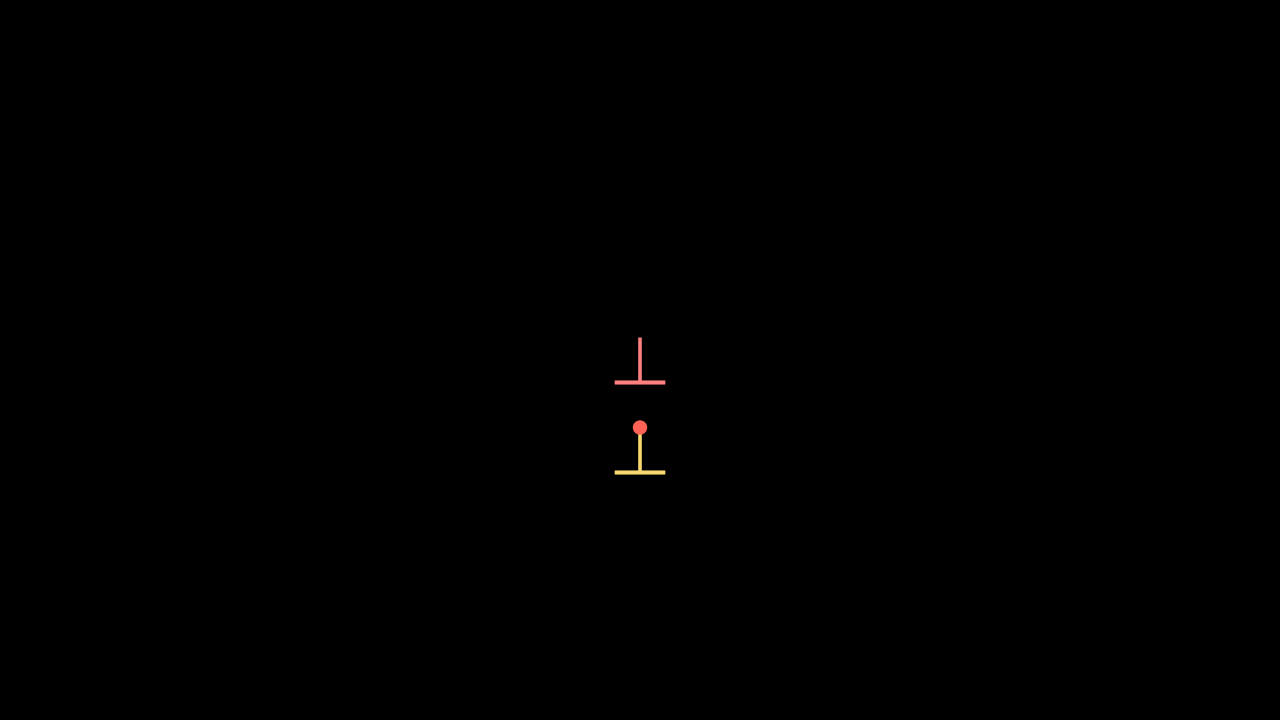

In [15]:
%%manim -qm groundDemo

class groundDemo(Scene):
    def construct(self):
        ground = Ground(center=DOWN*1.0, color=YELLOW)
        base_ground = Ground(color=RED_B)
        conn = ground.get_conn()
        self.add(
            ground,
            base_ground,
            conn,
        )

In [16]:
%%manim -qm GroundFlashDemo

class GroundFlashDemo(Scene):
    def construct(self):
        flashDemo1(self, Ground(color=YELLOW))

Manim Community v0.20.1

In [17]:
%%manim -qm GroundRotateDemo

class GroundRotateDemo(Scene):
    def construct(self):
        ground = Ground(color=YELLOW)
        rotateDemo1(self, ground)

Manim Community v0.20.1

In [18]:
%%manim -qm GroundShiftDemo

class GroundShiftDemo(Scene):
    def construct(self):
        ground = Ground(color=YELLOW)
        shiftDemo1(self, ground)

Manim Community v0.20.1

In [19]:
%%manim -qm GroundScaleDemo

class GroundScaleDemo(Scene):
    def construct(self):
        ground = Ground(color=YELLOW)
        scaleDemo1(self, ground)

Manim Community v0.20.1

## Power Connection

In [20]:
class OriginalPower(VMobject):
    def __init__(self, conn = UP*0.0125, center=ORIGIN, **kwargs):
        self.center = center

        self.connection = Connection(conn, color=RED)

        super().__init__(**kwargs)

    def get_conn(self) -> Vector3D:
        return self.connection.get_center()

    def generate_points(self):
        self.add(Arrow(
            DOWN*0.125, UP*0.125,
            color=YELLOW,
            tip_style={'fill_opacity': 0.5, 'stroke_width': 0.5},
            max_tip_length_to_length_ratio=0.5,
            max_stroke_width_to_length_ratio=20.0
        ))
        

    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP,
                coords[i][0]*RIGHT+coords[i][1]*UP
            ))

In [ ]:
class Power(Component1):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center

        super().__init__(center=self.mcenter, conn=0.25*DOWN, **kwargs)

    def generate_points(self):
        self.add(Arrow(
            start = 0.5*DOWN+self.mcenter,
            end = 0.75*UP+self.mcenter,
            tip_style={'fill_opacity': 0.5, 'stroke_width': 0.5},
            max_tip_length_to_length_ratio=0.5,
            max_stroke_width_to_length_ratio=20.0
        ))

Manim Community v0.20.1

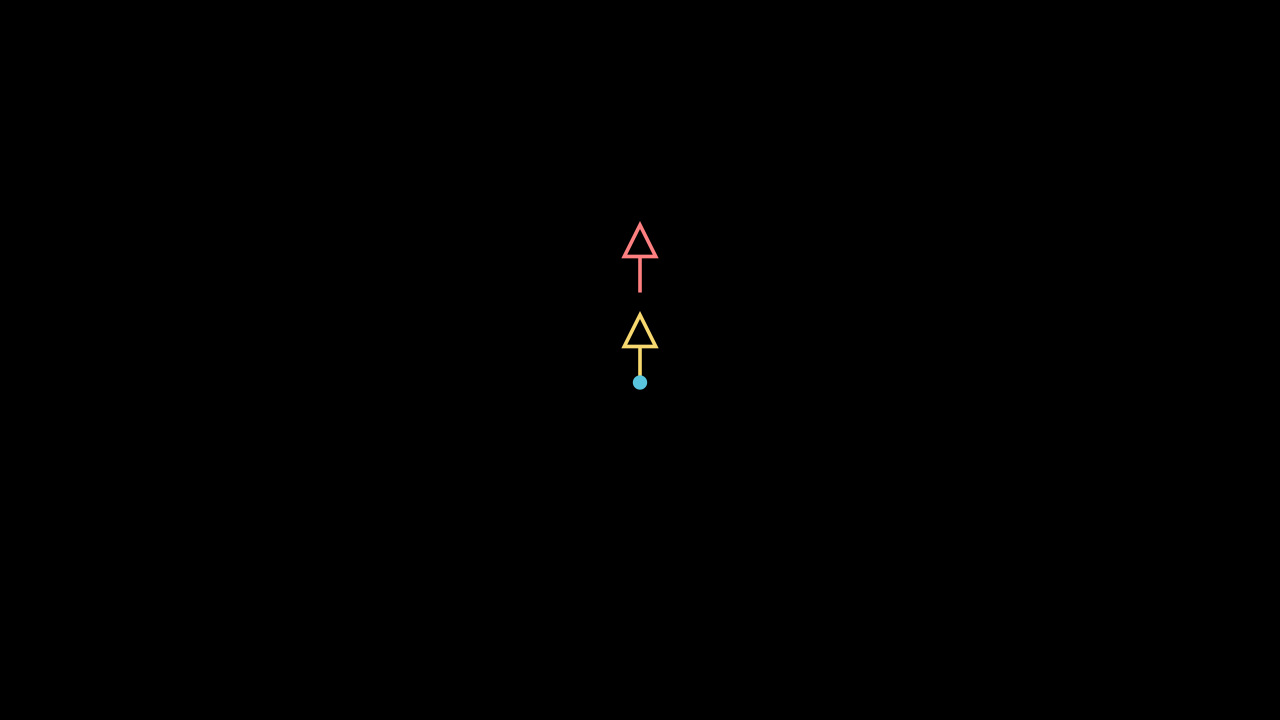

In [24]:
%%manim -qm powerDemo

class powerDemo(Scene):
    def construct(self):
        power = Power(color=YELLOW)
        shifted_power = Power(center=UP, color=RED_B)
        conn = power.get_conn().set_color(BLUE)
        self.add(
            power,
            shifted_power,
            conn,
        )

In [23]:
%%manim -qm groundFlashDemo

class groundFlashDemo(Scene):
    def construct(self):
        flashDemo1(self, Power(color=YELLOW))

Manim Community v0.20.1

In [22]:
%%manim -qm PowerRotateDemo

class PowerRotateDemo(Scene):
    def construct(self):
        power = Power(color=YELLOW)
        rotateDemo1(self, power)

Manim Community v0.20.1

In [23]:
%%manim -qm PowerShiftDemo

class PowerShiftDemo(Scene):
    def construct(self):
        power = Power(color=YELLOW)
        shiftDemo1(self, power)

Manim Community v0.20.1

In [24]:
%%manim -qm PowerScaleDemo

class PowerScaleDemo(Scene):
    def construct(self):
        power = Power(color=YELLOW)
        scaleDemo1(self, power)

Manim Community v0.20.1

# Component2

In [131]:
# A component mobject with 2 connection points
class Component2(Component):
    def __init__(
            self,
            center= ORIGIN,
            conn_a: Vector3D = 1.0*UP,
            conn_b: Vector3D = 1.0*DOWN,
            initial_rot=0.0, # TODO: Make ability to instantiate resistor with initial rotation
            radius=1.0,
            **kwargs
    ) -> None:
        # TODO: Maybe make a *connections array for components to be added to for the child component classes
        self.mcenter = center

        self.conn_a = Connection(self.mcenter+radius*conn_a, color = RED)
        self.conn_b = Connection(self.mcenter+radius*conn_b, color = BLUE)

        super().__init__(**kwargs)

    def get_conn_a(self) -> Connection | Vector3D:
        return self.conn_a
    def get_conn_b(self) -> Connection | Vector3D:
        return self.conn_b 
    def get_center(self) -> Vector3D:
        return self.mcenter
    def set_conn_a(self, val: Connection | Vector3D):
        self.conn_a = val
        return self
    def set_conn_b(self, val: Connection | Vector3D):
        self.conn_b = val
        return self
    
    def scale(self, alpha: float, **kwargs):
        self.conn_a.scale(alpha, about_point=self.get_center())
        self.conn_b.scale(alpha, about_point=self.get_center())
        super().scale(alpha, about_point=self.get_center(), **kwargs)
        return self

    def rotate(self, theta: float, **kwargs):
        self.conn_a.rotate(theta, about_point=self.get_center())
        self.conn_b.rotate(theta, about_point=self.get_center())
        
        super().rotate(theta, **kwargs)
        return self
    
    def shift(self, *vectors: Vector3DLike, **kwargs):
        # TODO: Make shiftDemo function
        self.conn_a.shift(vectors)
        self.conn_b.shift(vectors)
        super().shift(vectors)
        return self


In [27]:
def rotateDemo2(
        self, # Scene
        comp,
    ):
    component = comp.copy()
    conn_a = always_redraw(lambda: component.get_conn_a())
    conn_b = always_redraw(lambda: component.get_conn_b())

    theta_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.rotate(dt*theta_tracker.get_value())
    )

    self.play(Create(component))

    rotation = TAU/3
    run_time = 2

    theta_tracker.set_value(rotation/run_time)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep rotating through it
    theta_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color)
    )

    theta_tracker.set_value(-rotation/run_time)
    self.wait(run_time*2)
    
    theta_tracker.set_value(rotation/run_time)
    self.wait(run_time)

    theta_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [28]:
def scaleDemo2(
        self,
        comp
):
    component = comp.copy()
    conn_a = always_redraw(lambda: component.get_conn_a())
    conn_b = always_redraw(lambda: component.get_conn_b())

    scale_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.scale(1+dt*scale_tracker.get_value())
    )

    self.play(Create(component))
    run_time = 2.0

    scale_tracker.set_value(1.0/run_time)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep rotating through it
    scale_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color)
    )

    scale_tracker.set_value(-1.0/run_time)
    self.wait(run_time*2)
    
    scale_tracker.set_value(1.0/run_time)
    self.wait(run_time)

    scale_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [29]:
def shiftDemo2(
        self,
        comp
):
    component = comp.copy()
    conn_a = always_redraw(lambda: component.get_conn_a())
    conn_b = always_redraw(lambda: component.get_conn_b())

    h_shift_tracker = ValueTracker(0)
    v_shift_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.shift(dt*(h_shift_tracker.get_value()*RIGHT+v_shift_tracker.get_value()*UP))
    )

    self.play(Create(component))
    run_time = 1.0

    h_shift_tracker.set_value(3)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep shifting through it
    h_shift_tracker.set_value(0)
    v_shift_tracker.set_value(3)
    self.wait(run_time)

    v_shift_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color)
    )

    h_shift_tracker.set_value(-3)
    self.wait(run_time)

    v_shift_tracker.set_value(-3)
    h_shift_tracker.set_value(0)
    self.wait(run_time)

    
    v_shift_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(Uncreate(component))

In [30]:
def flashDemo2(self, comp):
    component = comp.copy()
    conn_a = Dot(component.get_conn_a().get_center(), color=RED)
    conn_b = Dot(component.get_conn_b().get_center(), color=BLUE)
    self.play(
        Create(component)
    )
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color),
    )
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

## Resistor

In [31]:
# Likely to be disregarded but kept for archival purposes
class OriginalResistor(VMobject):
    def __init__(self, center=ORIGIN, initial_rot=0.0, radius=1.0, **kwargs) -> None:
        self.center = center

        # TODO: Make ability to instantiate resistor with initial rotation
        
        self.conn_a = Connection(center+radius*UP, color = RED)
        self.conn_b = Connection(center+radius*DOWN, color = BLUE)

        # TODO: Make a calculation to find the true radius of the component
        self.radius = radius
        
        # [RIGHT coord, UP coord]
        self.coords = [
            [0.0, 1.0],
            [0.0, 0.6236559139784945],
            [0.15053763440860216, 0.4946236559139785],
            [-0.15053763440860216, 0.25806451612903225],
            [0.15053763440860216, 0.02150537634408602],
            [-0.15053763440860216, -0.1935483870967742],
            [0.15053763440860216, -0.4408602150537634],
            [0.0, -0.5698924731182796],
            [0.0, -1.0]
        ]

        super().__init__(**kwargs)
    
    def get_conn_a(self) -> Connection | Vector3D:
        return self.conn_a
    
    def get_conn_b(self) -> Connection | Vector3D:
        return self.conn_b
    
    def get_center(self) -> Vector3D:
        return self.center

    def set_conn_a(self, val: Connection | Vector3D):
        self.conn_a = val
        return self
    
    def set_conn_b(self, val: Connection | Vector3D):
        self.conn_b = val
        return self
    
    '''
        dx = self.radius*np.sin(theta)
        dy = self.radius*np.sin(theta)*np.tan(np.mod(theta/2, PI))

        x_sign = -1.0 if self.get_tot_rot() > 0 else 1.0
        y_sign = -1.0 if ((self.get_tot_rot() >= PI/2) and (self.get_tot_rot())) < -PI/2 else 1.0
        if (theta < 0):
            x_sign = -1.0 if x_sign > 0 else 1.0
            y_sign = -1.0 if y_sign > 0 else 1.0
        self.update_vars(
            self.conn_a + x_sign*dx*LEFT - y_sign*dy*UP,
            self.conn_b - x_sign*dx*LEFT + y_sign*dy*UP,
            ((self.get_tot_rot()+theta) % PI)
        )
    '''

    def rotate(self, theta: float, **kwargs):
        self.conn_a.rotate(theta, about_point=self.get_center())
        self.conn_b.rotate(theta, about_point=self.get_center())
        
        super().rotate(theta, **kwargs)
        return self
    
    def shift(self, *vectors: Vector3DLike, **kwargs):
        super().shift(vectors)
        return self

    def generate_points(self):
        self.start_new_path(self.center)
        self.set_points_as_corners(self.get_coords())

    def get_coords(self):
        return [coord[1]*UP + coord[0]*RIGHT for coord in self.coords]

In [132]:
class Resistor(Component2):
    def __init__(self, center=ORIGIN, initial_rot=0.0, radius=1.0, **kwargs) -> None:
        # [RIGHT coord, UP coord]
        self.mcenter = center

        self.coords: list[Vector2D] = [
            [0.0, 1.0],
            [0.0, 0.6236559139784945],
            [0.15053763440860216, 0.4946236559139785],
            [-0.15053763440860216, 0.25806451612903225],
            [0.15053763440860216, 0.02150537634408602],
            [-0.15053763440860216, -0.1935483870967742],
            [0.15053763440860216, -0.4408602150537634],
            [0.0, -0.5698924731182796],
            [0.0, -1.0]
        ]

        super().__init__(conn_a=1.0*UP, conn_b=1.0*DOWN, center = self.mcenter, **kwargs)

    def generate_points(self):
        self.start_new_path(self.center)
        self.set_points_as_corners(self.get_coords())

    def get_coords(self):
        return [coord[1]*UP + coord[0]*RIGHT + self.mcenter for coord in self.coords]

Manim Community v0.20.1

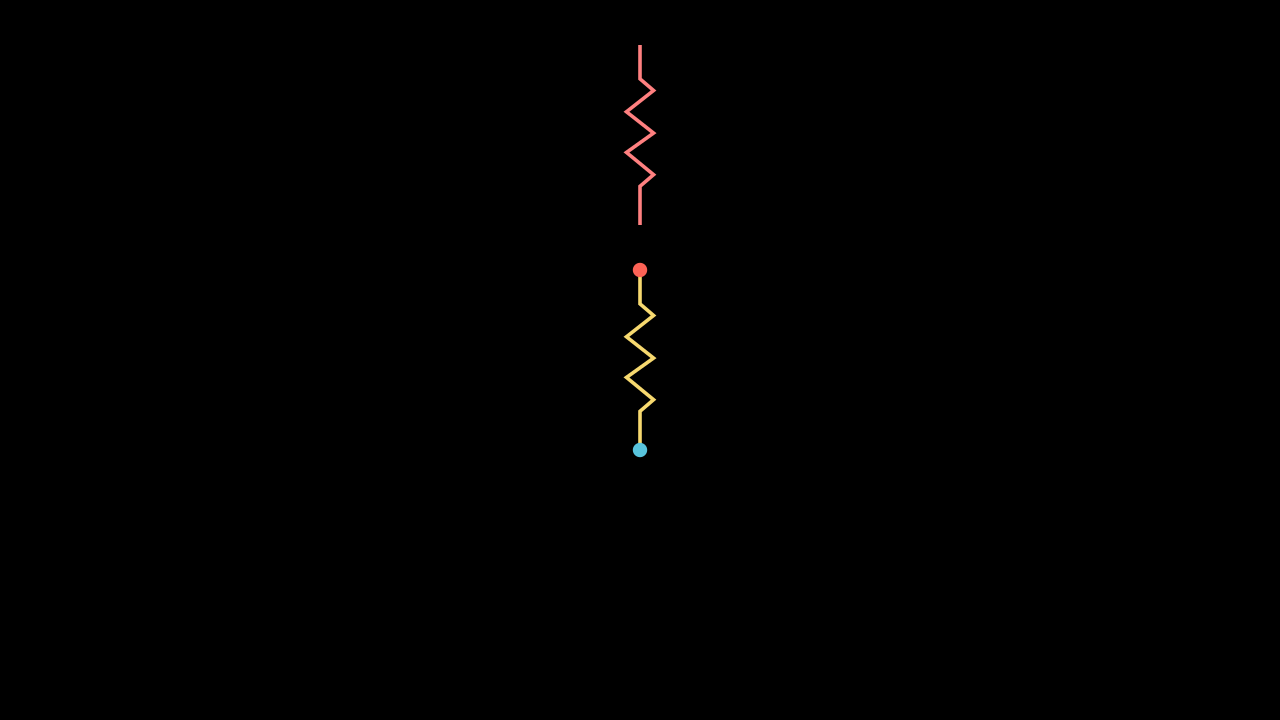

In [133]:
%%manim -qm ResistorDemo

class ResistorDemo(Scene):
    def construct(self):
        res = Resistor(color=YELLOW)
        shifted_res = Resistor(center=UP*2.5, color=RED_B)
        self.add(
            res,
            shifted_res,
            Dot(res.get_conn_a().get_center(), color=RED),
            Dot(res.get_conn_b().get_center(), color=BLUE)
        )

In [35]:
%%manim -qm ResistorRotateDemo

class ResistorRotateDemo(Scene):
    def construct(self):
        rotateDemo2(self, Resistor(color=YELLOW).rotate(PI/2))

Manim Community v0.20.1

In [34]:
%%manim -qm ResistorFlashDemo

class ResistorFlashDemo(Scene):
    def construct(self):
        flashDemo2(self, Resistor(color=YELLOW))

Manim Community v0.20.1

In [35]:
%%manim -qm ResistorScaleDemo

class ResistorScaleDemo(Scene):
    def construct(self):
        res = Resistor(color=YELLOW)
        scaleDemo2(self, res)

Manim Community v0.20.1

In [36]:
%%manim -qm ResistorShiftDemo

class ResistorShiftDemo(Scene):
    def construct(self):
        res = Resistor(color=YELLOW)
        shiftDemo2(self, res)

Manim Community v0.20.1

## Capacitor

In [38]:
class Capacitor(Component2):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center

        # [RIGHT, UP]
        # Coordinates of top lines
        self.top_coords = [
            [0.0, 1.0],
            [0.0, 0.085],
            [0.2, 0.085],
            [-0.2, 0.085]
        ]

        # Bottom vertical line
        self.bottom_coords = [
            [0.0, 0.0],
            [0.0, -1.0]
        ]

        super().__init__(conn_a=1.0*UP, conn_b=1.0*DOWN, center = self.mcenter, **kwargs)
    
    def generate_points(self):
        # Top section
        self.add(
            Line(
                self.top_coords[1][0]*RIGHT+self.top_coords[1][1]*UP+self.mcenter,
                self.top_coords[0][0]*RIGHT+self.top_coords[0][1]*UP+self.mcenter
            ),
            Line(
                
                self.top_coords[3][0]*RIGHT+self.top_coords[3][1]*UP+self.mcenter,
                self.top_coords[2][0]*RIGHT+self.top_coords[2][1]*UP+self.mcenter
            )
        )

        # Bottom Arc
        ang_cen = PI*0.5
        ang = PI*0.5
        self.add(
            Arc(0.25, ang_cen, -0.5*ang, arc_center=DOWN*0.2325+self.mcenter),
            Arc(0.25, ang_cen, ang*0.5, arc_center=DOWN*0.2325+self.mcenter)
        )
        
        # Bottom Vertical Line
        self.add(Line(
            self.bottom_coords[0][0]*RIGHT+self.bottom_coords[0][1]*UP+self.mcenter,
            self.bottom_coords[1][0]*RIGHT+self.bottom_coords[1][1]*UP+self.mcenter
        ))

Manim Community v0.20.1

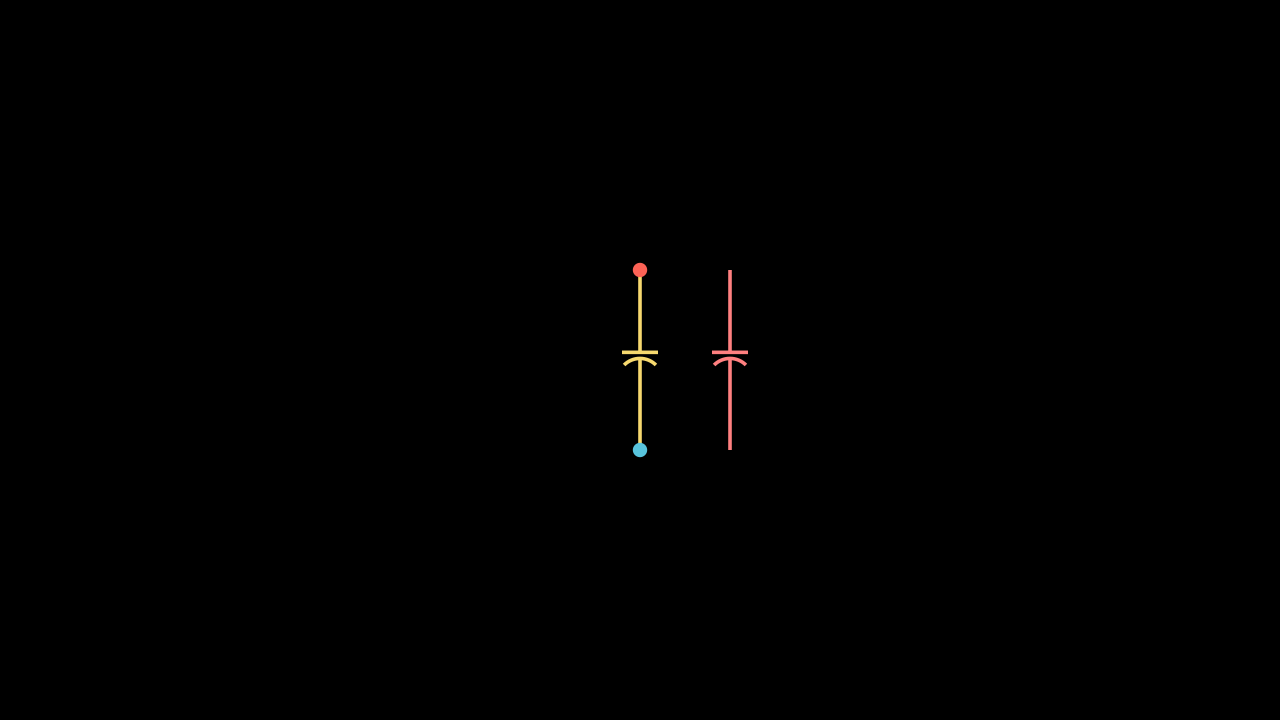

In [40]:
%%manim -qm CapacitorDemo

class CapacitorDemo(Scene):
    def construct(self):
        cap = Capacitor(color=YELLOW)
        shifted_cap = Capacitor(center=RIGHT, color=RED_B)
        self.add(
            cap,
            shifted_cap,
            Dot(cap.get_conn_a().get_center(), color=RED),
            Dot(cap.get_conn_b().get_center(), color=BLUE)
        )

In [39]:
%%manim -qm CapacitorRotateDemo

class CapacitorRotateDemo(Scene):
    def construct(self):
        rotateDemo2(self, Capacitor(color=YELLOW).rotate(PI/2))

Manim Community v0.20.1

In [40]:
%%manim -qm CapacitorScaleDemo

class CapacitorScaleDemo(Scene):
    def construct(self):
        cap = Capacitor(color=YELLOW)
        scaleDemo2(self, cap)

Manim Community v0.20.1

In [41]:
%%manim -qm CapacitorShiftDemo

class CapacitorShiftDemo(Scene):
    def construct(self):
        cap = Capacitor(color=YELLOW)
        shiftDemo2(self, cap)

Manim Community v0.20.1

In [42]:
%%manim -qm CapacitorFlashDemo

class CapacitorFlashDemo(Scene):
    def construct(self):
        flashDemo2(self, Capacitor(color=YELLOW))

Manim Community v0.20.1

## 2-Way Switch

In [41]:
class Switch2(Component2):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center

        # [RIGHT, UP] 0.35
        # Coordinates of top lines
        self.left_coords = [
            [-1.0, 0.0],
            [-0.4286, 0.0],
            [0.4286, 0.2714]
        ]
        self.right_coords = [
            [0.2857, 0.0],
            [1.0, 0.0]
        ]
        self.top_connection = [
            [0.0, 0.1357],
            [0.0, 0.2857]
        ]
        self.top_squiggle = [
            [0.0, 0.4],
            [0.0, 0.4857],
            [-0.1571, 0.5857],
            [0.0, 0.6857],
            [0.0, 0.8286],
        ]
        self.top_lines = [
            [0.0, 0.9143],
            [0.0, 1.314],
            [-0.4143, 1.314],
            [0.3857, 1.314],
            [0.3857, 1.0],
            [0.3857, 1.643],
        ]

        super().__init__(conn_a=LEFT*1.0, conn_b=RIGHT*1.0, center=self.mcenter, **kwargs)
    
    def generate_points(self):
        self.add_points(self.left_coords)
        self.add_points(self.right_coords)
        self.add_points(self.top_connection)
        self.add_points(self.top_squiggle)
        self.add_points(self.top_lines)

    def rotate(self, theta, **kwargs):
        super().rotate(theta, about_point=self.get_center(), **kwargs)
        
    
    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
            ))

Manim Community v0.20.1

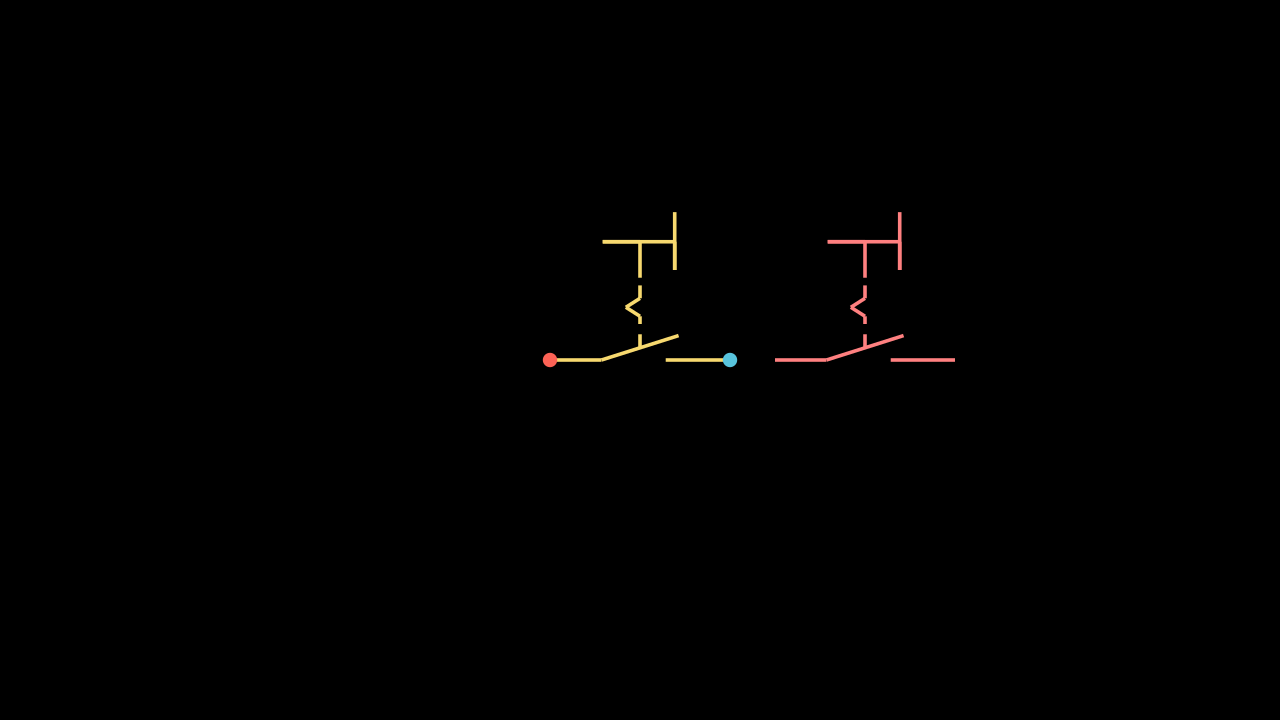

In [43]:
%%manim -qm Switch2Demo

class Switch2Demo(Scene):
    def construct(self):
        sw = Switch2(color=YELLOW)
        shifted_sw = Switch2(center=RIGHT*2.5, color=RED_B)
        self.add(
            sw,
            shifted_sw,
            Dot(sw.get_conn_a().get_center(), color=RED),
            Dot(sw.get_conn_b().get_center(), color=BLUE)
        )

In [45]:
%%manim -qm Switch2RotateDemo

class Switch2RotateDemo(Scene):
    def construct(self):
        rotateDemo2(self, Switch2(color=YELLOW))

Manim Community v0.20.1

In [46]:
%%manim -qm Switch2ScaleDemo

class Switch2ScaleDemo(Scene):
    def construct(self):
        sw = Switch2(color=YELLOW)
        scaleDemo2(self, sw)

Manim Community v0.20.1

In [47]:
%%manim -qm Switch2ShiftDemo

class Switch2ShiftDemo(Scene):
    def construct(self):
        sw = Switch2(color=YELLOW)
        shiftDemo2(self, sw)

Manim Community v0.20.1

In [48]:
%%manim -qm Switch2FlashDemo

class Switch2FlashDemo(Scene):
    def construct(self):
        flashDemo2(self, Switch2(color=YELLOW))

Manim Community v0.20.1

## LED

In [46]:
class LED(Component2):
    def __init__(self, center=ORIGIN, **kwargs):

        self.mcenter = center

        # [RIGHT, UP]
        self.main_line = [
            [0.0, 1.0],
            [0.0, -1.0]
        ]

        a = np.sqrt(3)/5
        self.triangle = [
            [-a, 0.4], # top left
            [a, 0.4], # top right
            [0, -0.2], # bottom
            [-a, 0.4] # top left
        ]

        self.diode_line  = [
            [0.4, -0.16],
            [-0.4, -0.16]
        ]

        self.arr1 = [
            [-0.5, 0.56/9],
            [-0.96, -101/225],
            [-0.61, -2.78/9],
            [-0.865, -0.845/9],
            [-0.94, -101/225],
        ]
        # y = 1.2x+0.14
        # (-0.175+0.1*a, -0.05+a/9)

        self.arr2 = [
            [-0.5, 104/225],
            [-0.96, -11/225],
            [-0.61, 41/450],
            [-0.865, 551/1800],
            [-0.96, -2/45],
        ]

        super().__init__(conn_a=UP*1.0, conn_b=DOWN*1.0, center=self.mcenter, **kwargs)

    def generate_points(self):
        self.add_points(self.main_line)
        self.add_points(self.triangle)
        self.add_points(self.diode_line)
        self.add_points(self.arr1)
        self.add_points(self.arr2)

    def rotate(self, theta: float, **kwargs):
        super().rotate(theta, about_point=self.get_center(), **kwargs)
        return self

    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
            ))

Manim Community v0.20.1

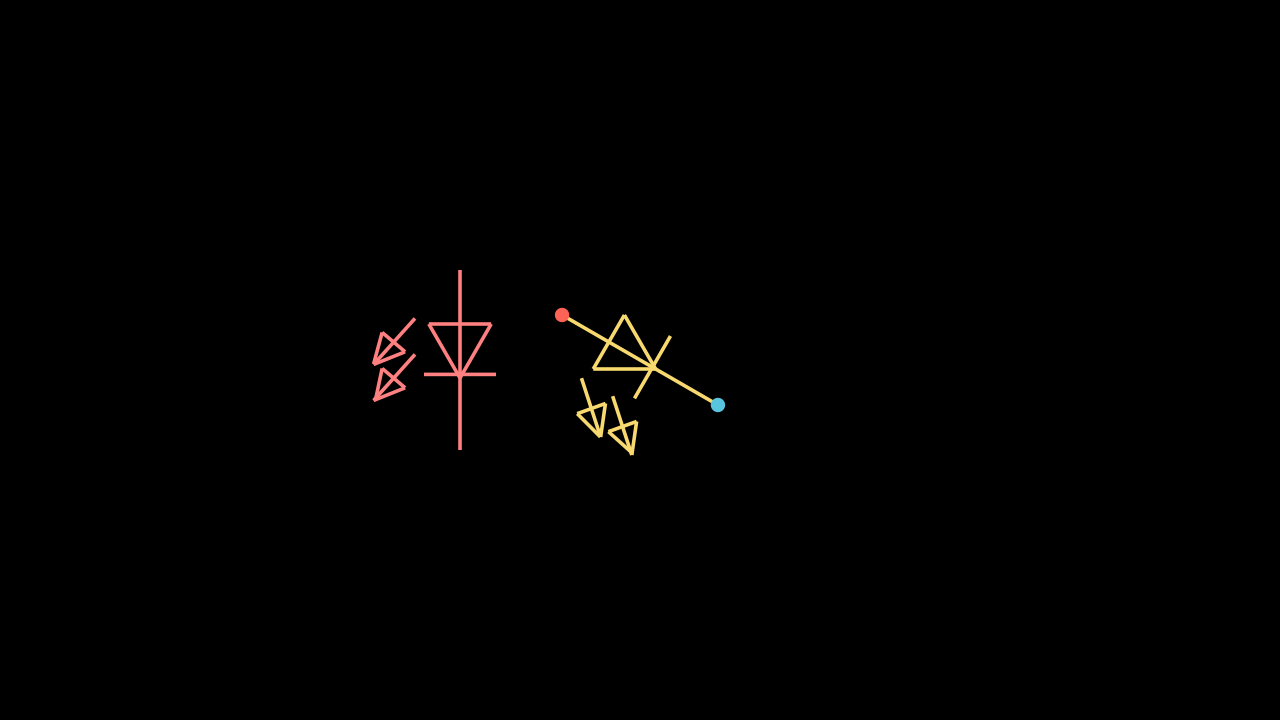

In [47]:
%%manim -qm ledDemo

class ledDemo(Scene):
    def construct(self):
        led = LED(color=YELLOW).rotate(PI/3)
        shifted_led = LED(center=LEFT*2, color=RED_B)
        self.add(
            led,
            shifted_led,
            Dot(led.get_conn_a().get_center(), color=RED),
            Dot(led.get_conn_b().get_center(), color=BLUE),
        )

In [51]:
%%manim -qm LedFlashDemo

class LedFlashDemo(Scene):
    def construct(self):
        flashDemo2(self, LED(color=YELLOW))

Manim Community v0.20.1

In [52]:
%%manim -qm LedRotateDemo

class LedRotateDemo(Scene):
    def construct(self):
        led = LED(color=YELLOW)
        rotateDemo2(self, led)

Manim Community v0.20.1

In [53]:
%%manim -qm LedScaleDemo

class LedScaleDemo(Scene):
    def construct(self):
        led = LED(color=YELLOW)
        scaleDemo2(self, led)

Manim Community v0.20.1

In [54]:
%%manim -qm LedShiftDemo

class LedShiftDemo(Scene):
    def construct(self):
        led = LED(color=YELLOW)
        shiftDemo2(self, led)

Manim Community v0.20.1

## Voltage Source

In [53]:
class VoltageSource(Component2):
    def __init__(self, center = ORIGIN, **kwargs):
        self.mcenter = center

        # Plus
        self.v_plus_coords = [
            [0.0, 0.375],
            [0.0, 0.125]
        ]
        self.h_plus_coords = [
            [-0.125, 0.25],
            [0.125, 0.25]
        ]

        # Minus
        self.minus_coords = [
            [0.125, -0.25],
            [-0.125, -0.25]
        ]

        # Connections
        self.top_connection_coords = [
            [0.0, 0.5],
            [0.0, 1.0]
        ]
        self.bottom_connection_coords = [
            [0.0, -0.5],
            [0.0, -1.0]
        ]

        super().__init__(conn_a=1.0*UP, conn_b=1.0*DOWN, center=self.mcenter, **kwargs)
    
    def generate_points(self):
        self.add_points(self.top_connection_coords)
        self.add(Circle(radius=0.5).shift(self.mcenter))
        self.add_points(self.v_plus_coords)
        self.add_points(self.h_plus_coords)
        self.add_points(self.minus_coords)
        self.add_points(self.bottom_connection_coords)

    def add_points(self, *coords_list):
        for coords in coords_list:
            for i in (range(coords.__len__()-1)):
                self.add(Line(
                    coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                    coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
                ))

Manim Community v0.20.1

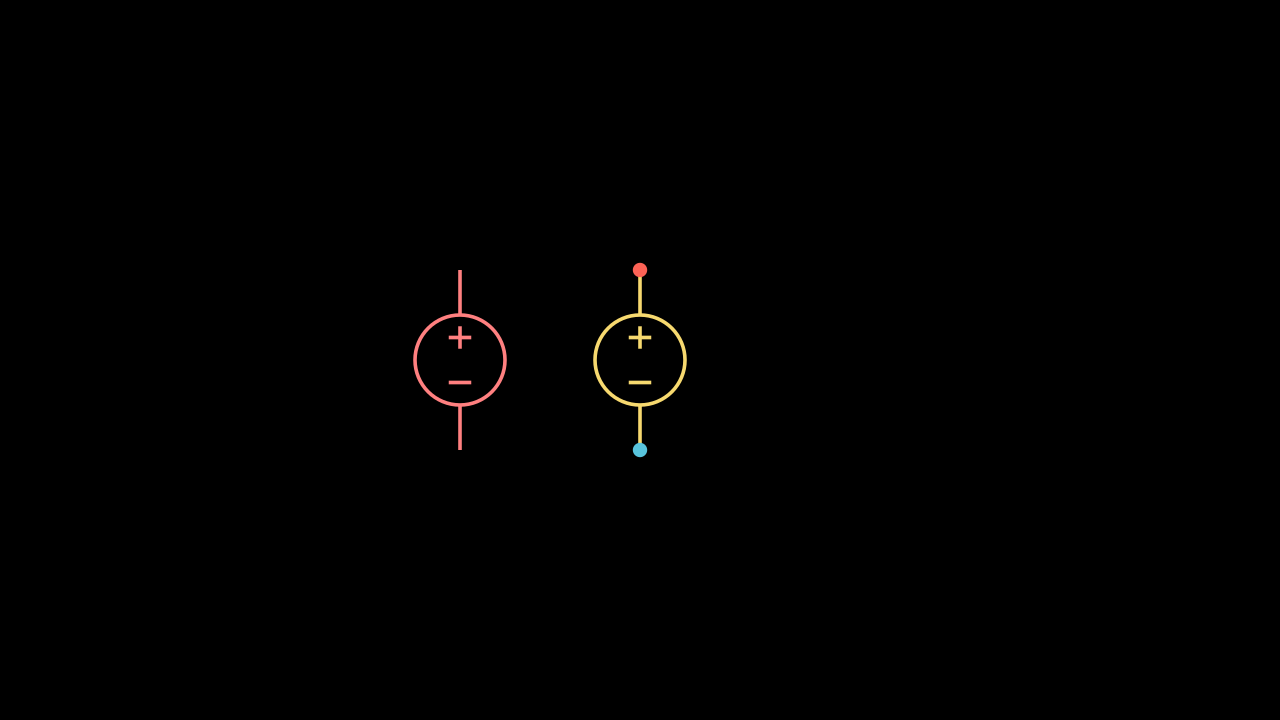

In [54]:
%%manim -qm VoltageSourceDemo

class VoltageSourceDemo(Scene):
    def construct(self):
        vs = VoltageSource(color=YELLOW)
        shifted_vs = VoltageSource(center=LEFT*2, color=RED_B)
        self.add(
            vs,
            shifted_vs,
            Dot(vs.get_conn_a().get_center(), color=RED),
            Dot(vs.get_conn_b().get_center(), color=BLUE),
        )

In [57]:
%%manim -qm VoltageSourceFlashDemo

class VoltageSourceFlashDemo(Scene):
    def construct(self):
        vs = VoltageSource(color=YELLOW)
        flashDemo2(self, vs)

Manim Community v0.20.1

In [58]:
%%manim -qm VoltageSourceRotateDemo

class VoltageSourceRotateDemo(Scene):
    def construct(self):
        vs = VoltageSource(color=YELLOW)
        rotateDemo2(self, vs)

Manim Community v0.20.1

In [59]:
%%manim -qm VoltageSourceScaleDemo

class VoltageSourceScaleDemo(Scene):
    def construct(self):
        vs = VoltageSource(color=YELLOW)
        scaleDemo2(self, vs)

Manim Community v0.20.1

In [60]:
%%manim -qm VoltageSourceShiftDemo

class VoltageSourceShiftDemo(Scene):
    def construct(self):
        vs = VoltageSource(color=YELLOW)
        shiftDemo2(self, vs)

Manim Community v0.20.1

## Current Source

In [55]:
class CurrentSource(Component2):
    def __init__(self, center = ORIGIN, **kwargs):
        self.mcenter = center

        self.arrow_coords = [
            [0.0, -0.45],
            [0.0, 0.45]
        ]

        # Connections
        self.top_connection_coords = [
            [0.0, 0.5],
            [0.0, 1.0]
        ]
        self.bottom_connection_coords = [
            [0.0, -0.5],
            [0.0, -1.0]
        ]

        super().__init__(conn_a=1.0*UP, conn_b=1.0*DOWN, center=self.mcenter, **kwargs)
    
    def generate_points(self):
        self.add_points(self.top_connection_coords)
        self.add(Circle(radius=0.5).shift(self.mcenter))
        self.add(Arrow(
            self.arrow_coords[0][0]*RIGHT + self.arrow_coords[0][1]*UP + self.mcenter,
            self.arrow_coords[1][0]*RIGHT + self.arrow_coords[1][1]*UP + self.mcenter,
            tip_style={'fill_opacity': 0.5, 'stroke_width': 0.5},
            max_tip_length_to_length_ratio=0.5,
            max_stroke_width_to_length_ratio=20.0
        ))
        self.add_points(self.bottom_connection_coords)

    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
            ))

Manim Community v0.20.1

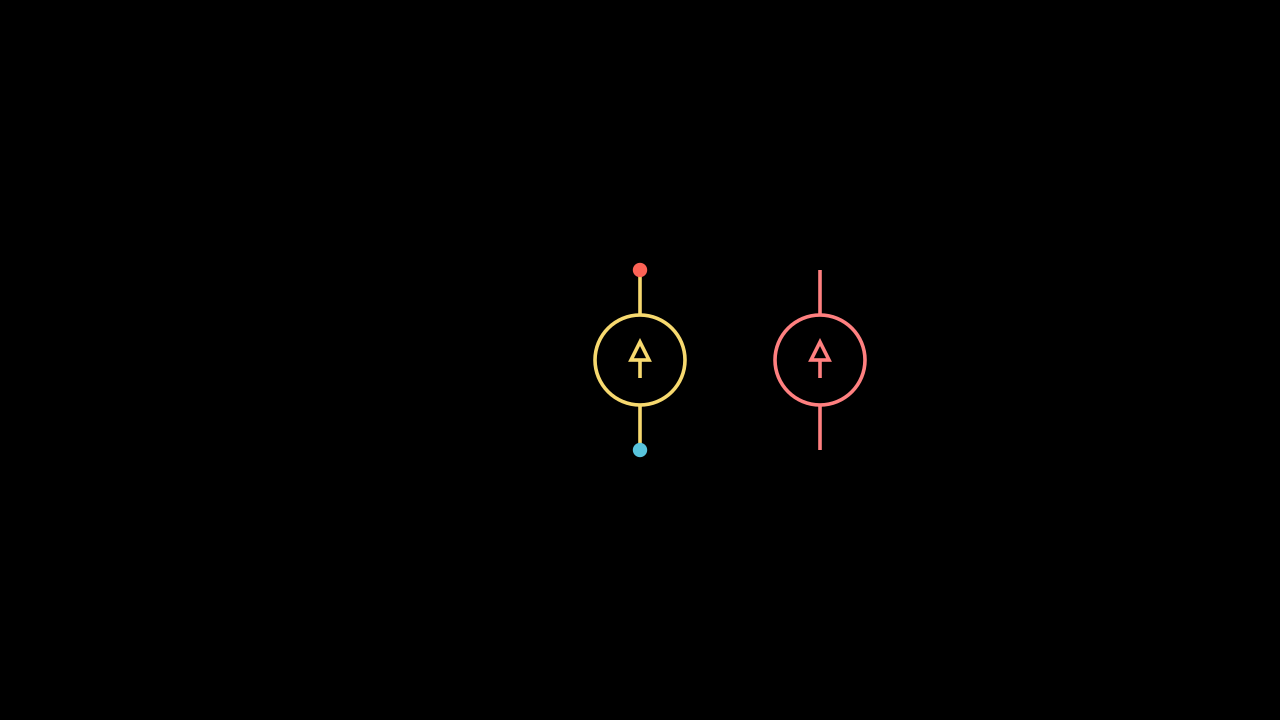

In [59]:
%%manim -qm CurrentSourceDemo

class CurrentSourceDemo(Scene):
    def construct(self):
        cs = CurrentSource(color=YELLOW)
        shifted_cs = CurrentSource(center=RIGHT*2, color=RED_B)
        self.add(
            cs,
            shifted_cs,
            Dot(cs.get_conn_a().get_center(), color=RED),
            Dot(cs.get_conn_b().get_center(), color=BLUE),
        )

In [63]:
%%manim -qm CurrentSourceFlashDemo

class CurrentSourceFlashDemo(Scene):
    def construct(self):
        cs = CurrentSource(color=YELLOW)
        flashDemo2(self, cs)

Manim Community v0.20.1

In [64]:
%%manim -qm CurrentSourceRotateDemo

class CurrentSourceRotateDemo(Scene):
    def construct(self):
        cs = CurrentSource(color=YELLOW)
        rotateDemo2(self, cs)

Manim Community v0.20.1

In [65]:
%%manim -qm CurrentSourceScaleDemo

class CurrentSourceScaleDemo(Scene):
    def construct(self):
        cs = CurrentSource(color=YELLOW)
        scaleDemo2(self, cs)

Manim Community v0.20.1

In [66]:
%%manim -qm CurrentSourceShiftDemo

class CurrentSourceShiftDemo(Scene):
    def construct(self):
        cs = CurrentSource(color=YELLOW)
        shiftDemo2(self, cs)

Manim Community v0.20.1

## Battery

In [60]:
class Battery(Component2):
    def __init__(self, center = ORIGIN, **kwargs):
        self.mcenter = center

        self.top_connection = [
            [0.0, 1.0],
            [0.0, 0.2]
        ]
        self.top_big_line = [
            [0.35, 0.2],
            [-0.35, 0.2],
        ]
        self.top_small_line = [
            [0.2, 0.075],
            [-0.2, 0.075],
        ]
        self.bottom_big_line = [
            [0.35, -0.075],
            [-0.35, -0.075],
        ]
        self.bottom_small_line = [
            [0.2, -0.2],
            [-0.2, -0.2],
        ]
        self.bottom_connection = [
            [0.0, -0.2],
            [0.0, -1.0]
        ]

        super().__init__(self.mcenter, **kwargs)
    
    def generate_points(self):
        self.add_points(self.top_connection)
        self.add_points(self.top_big_line)
        self.add_points(self.top_small_line)
        self.add_points(self.bottom_big_line)
        self.add_points(self.bottom_small_line)
        self.add_points(self.bottom_connection)

    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
            ))

Manim Community v0.20.1

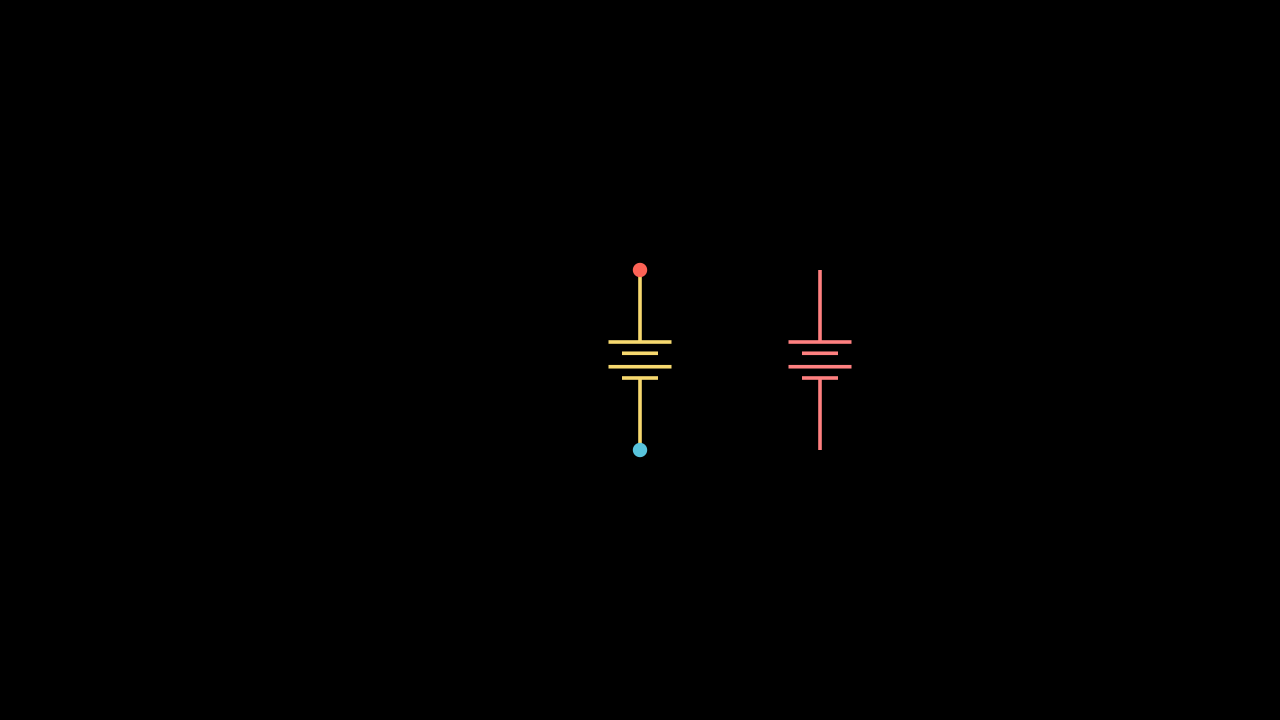

In [62]:
%%manim -qm BatteryDemo

class BatteryDemo(Scene):
    def construct(self):
        bat = Battery(color=YELLOW)
        shifted_bat = Battery(center=RIGHT*2, color=RED_B)
        self.add(
            bat,
            shifted_bat,
            Dot(bat.get_conn_a().get_center(), color=RED),
            Dot(bat.get_conn_b().get_center(), color=BLUE),
        )

In [69]:
%%manim -qm BatteryFlashDemo

class BatteryFlashDemo(Scene):
    def construct(self):
        bat = Battery(color=YELLOW)
        flashDemo2(self, bat)

Manim Community v0.20.1

In [70]:
%%manim -qm BatteryRotateDemo

class BatteryRotateDemo(Scene):
    def construct(self):
        bat = Battery(color=YELLOW)
        rotateDemo2(self, bat)

Manim Community v0.20.1

Waiting 1:   0%|          | 0/1 [00:00<?, ?it/s]                   

In [71]:
%%manim -qm BatteryScaleDemo

class BatteryScaleDemo(Scene):
    def construct(self):
        bat = Battery(color=YELLOW)
        scaleDemo2(self, bat)

Manim Community v0.20.1

In [72]:
%%manim -qm BatteryShiftDemo

class BatteryShiftDemo(Scene):
    def construct(self):
        bat = Battery(color=YELLOW)
        shiftDemo2(self, bat)

Manim Community v0.20.1

# Component3

In [135]:
class Component3(Component):
    def __init__(
            self,
            center= ORIGIN,
            conn_a: Vector3D = 1.0*UP, # TODO: Get proper default connections
            conn_b: Vector3D = 1.0*DOWN,
            conn_c: Vector3D = 1.0*RIGHT,
            initial_rot=0.0, # TODO: Make ability to instantiate resistor with initial rotation
            radius=1.0,
            **kwargs
    ) -> None:
        # TODO: Maybe make a *connections array for components to be added to for the child component classes
        self.mcenter = center

        self.conn_a = Connection(self.mcenter+radius*conn_a, color = RED)
        self.conn_b = Connection(self.mcenter+radius*conn_b, color = BLUE)
        self.conn_c = Connection(self.mcenter+radius*conn_c, color = GREEN)

        super().__init__(**kwargs)

    def get_conn_a(self) -> Connection | Vector3D:
        return self.conn_a
    def get_conn_b(self) -> Connection | Vector3D:
        return self.conn_b 
    def get_center(self) -> Vector3D:
        return self.self.mcenter
    def set_conn_a(self, val: Connection | Vector3D):
        self.conn_a = val
        return self
    def set_conn_b(self, val: Connection | Vector3D):
        self.conn_b = val
        return self
    def get_conn_c(self) -> Connection | Vector3D:
        return self.conn_c
    def set_conn_c(self, val: Connection | Vector3D):
        self.conn_c = val
        return self
    
    def scale(self, alpha: float, **kwargs):
        self.conn_a.scale(alpha, about_point=self.get_center())
        self.conn_b.scale(alpha, about_point=self.get_center())
        self.conn_c.scale(alpha, about_point=self.get_center())
        
        super().scale(alpha, about_point=self.get_center(), **kwargs)
        return self

    def rotate(self, theta: float, **kwargs):
        self.conn_a.rotate(theta, about_point=self.get_center())
        self.conn_b.rotate(theta, about_point=self.get_center())
        self.conn_c.rotate(theta, about_point=self.get_center())
        
        super().rotate(theta, **kwargs)
        return self
    
    def shift(self, *vectors: Vector3DLike, **kwargs):
        # TODO: Make shiftDemo function
        self.conn_a.shift(vectors)
        self.conn_b.shift(vectors)
        self.conn_c.shift(vectors)
        super().shift(vectors)
        return self

In [66]:
def flashDemo3(self, comp):
    component = comp.copy()
    conn_a = Dot(component.get_conn_a().get_center(), color=RED)
    conn_b = Dot(component.get_conn_b().get_center(), color=BLUE)
    conn_c = Dot(component.get_conn_c().get_center(), color=GREEN)
    self.play(
        Create(component)
    )
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color),
        GrowFromCenter(conn_c, point_color=component.color),
    )
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_c, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [67]:
def rotateDemo3(
        self, # Scene
        comp,
    ):
    component = comp.copy()
    conn_a = always_redraw(lambda: component.get_conn_a())
    conn_b = always_redraw(lambda: component.get_conn_b())
    conn_c = always_redraw(lambda: component.get_conn_c())

    theta_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.rotate(dt*theta_tracker.get_value(), about_point=x.get_center())
    )

    self.play(Create(component))

    rotation = TAU/3
    run_time = 2.0

    theta_tracker.set_value(rotation/run_time)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep rotating through it
    theta_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color),
        GrowFromCenter(conn_c, point_color=component.color)
    )

    theta_tracker.set_value(-rotation/run_time)
    self.wait(run_time*2)
    
    theta_tracker.set_value(rotation/run_time)
    self.wait(run_time)

    theta_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_c, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [68]:
def scaleDemo3(
        self,
        comp
):
    component = comp.copy()
    conn_a = always_redraw(lambda: component.get_conn_a())
    conn_b = always_redraw(lambda: component.get_conn_b())
    conn_c = always_redraw(lambda: component.get_conn_c())

    scale_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.scale(1.0+dt*scale_tracker.get_value())
    )

    self.play(Create(component))
    run_time = 2.0

    scale_tracker.set_value(1/run_time)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep rotating through it
    scale_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color),
        GrowFromCenter(conn_c, point_color=component.color)
    )

    scale_tracker.set_value(-1/run_time)
    self.wait(run_time*2)
    
    scale_tracker.set_value(1/run_time)
    self.wait(run_time)

    scale_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_c, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(
        Uncreate(component),
    )

In [69]:
def shiftDemo3(
        self,
        comp
):
    component = comp.copy()
    conn_a = always_redraw(lambda: component.get_conn_a())
    conn_b = always_redraw(lambda: component.get_conn_b())
    conn_c = always_redraw(lambda: component.get_conn_c())

    h_shift_tracker = ValueTracker(0)
    v_shift_tracker = ValueTracker(0)

    component.add_updater(lambda x, dt:
        x.shift(dt*(h_shift_tracker.get_value()*RIGHT+v_shift_tracker.get_value()*UP))
    )

    self.play(Create(component))
    run_time = 1.0

    h_shift_tracker.set_value(3)
    self.wait(run_time)

    # Set to 0 whenever other animation is happening so resistor doesn't keep shifting through it
    h_shift_tracker.set_value(0)
    v_shift_tracker.set_value(3)
    self.wait(run_time)

    v_shift_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color),
        GrowFromCenter(conn_b, point_color=component.color),
        GrowFromCenter(conn_c, point_color=component.color),
    )

    h_shift_tracker.set_value(-3)
    self.wait(run_time)

    v_shift_tracker.set_value(-3)
    h_shift_tracker.set_value(0)
    self.wait(run_time)

    
    v_shift_tracker.set_value(0)
    self.play(
        GrowFromCenter(conn_a, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_b, point_color=component.color, reverse_rate_function=1.0),
        GrowFromCenter(conn_c, point_color=component.color, reverse_rate_function=1.0)
    )
    self.play(Uncreate(component))

## Opamp

In [113]:
class Opamp(Component3):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center
        self.right = RIGHT*0.6589

        # Because I originally constructed this differently than all the other components, it may need reformatted to be constructed consistently with other components

        self.triangle_points = self.get_triangle_points(ORIGIN, self.right)
        
        # TODO: Maybe figure out if these should be Connections or Vector3Ds...we should just be consistent
        self.conn_a = LEFT*1.0+UP*0.3372 # Positive Connection
        self.conn_b = LEFT*1.0+DOWN*0.3372 # Negative Connection
        self.conn_c = RIGHT*1.0 # Output Connection

        self.sym_size = 0.07558
        self.pos_sym_pos = LEFT*0.4864+UP*0.3488
        self.neg_sym_pos = LEFT*0.4864+DOWN*0.3488

        self.pos_tri = RIGHT*self.triangle_points[1] + UP*self.pos_sym_pos # Point where positive connection connects to the triangle
        self.neg_tri = RIGHT*self.triangle_points[1] + UP*self.neg_sym_pos
        self.out_tri = RIGHT*0.6202

        # Negative symbol
        self.neg_sym = [self.sym_size*LEFT+self.neg_sym_pos, self.sym_size*RIGHT+self.neg_sym_pos]
        # Positive symbol requires 2 shapes
        self.h_pos_sym = [self.sym_size*LEFT+self.pos_sym_pos,self.sym_size*RIGHT+self.pos_sym_pos]
        self.v_pos_sym = [self.sym_size*UP+self.pos_sym_pos,self.sym_size*DOWN+self.pos_sym_pos]

        # Positive connection
        self.pos_conn = [self.conn_a, self.pos_tri*RIGHT+self.conn_a*UP]
        # Negative connection
        self.neg_conn = [self.conn_b, self.neg_tri*RIGHT+self.conn_b*UP]
        # Output connection
        self.out_conn = [self.out_tri, self.conn_c]

        super().__init__(conn_a=self.conn_a, conn_b=self.conn_b, conn_c=self.conn_c, center=self.mcenter, **kwargs)

    def generate_points(self):
        self.add_points(
            self.triangle_points,

            self.neg_sym,

            self.h_pos_sym,
            self.v_pos_sym,
            
            self.neg_conn,
            self.pos_conn,
            self.out_conn
        )
    
    def add_points(self, *coords_list):
        for coords in coords_list:
            for i in (range(coords.__len__()-1)):
                self.add(Line(
                    coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                    coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
                ))

    def get_norm(self, vect):
        return sum((x**2 for x in vect))**0.5
    
    def get_triangle_points(self, pc, pr):
        L = self.get_norm(pr - pc)
        h_stretch = 1.0875
        v_stretch = 0.55
        p1 = UP*(pc + L*np.sin((2-v_stretch)*PI/3)) + RIGHT*(pc + L*np.cos((2+h_stretch)*PI/3))
        p2 = UP*(pc + L*np.sin((4+v_stretch)*PI/3)) + RIGHT*(pc + L*np.cos((4-h_stretch)*PI/3))
        return [pr, p1, p2, pr]

In [114]:
# Consider using this MObject creation technique for items
class OriginalOpamp(VMobject):
    def __init__(self, center=ORIGIN, right=RIGHT, **kwargs):
        self.center = center
        self.right = right*0.8

        self.sym_size = 0.0975
        self.pos_sym_pos = LEFT*0.6275+UP*0.45
        self.neg_sym_pos = LEFT*0.6275+DOWN*0.45

        self.pos_conn = LEFT*1.29+UP*0.435
        self.neg_conn = LEFT*1.29+DOWN*0.435
        self.out_conn = RIGHT*1.29

        self.pos_tri = LEFT*0.8+UP*0.435 # Point where positive connection connects to the triangle
        self.neg_tri = LEFT*0.8+DOWN*0.435
        self.out_tri = RIGHT*0.8

        super().__init__(**kwargs)

    def create_new_shape(self, start: Vector3D, points: Vector):
        self.start_new_path(start) # Start a new path at the start point
        self.add_points_as_corners(points) # Add points to the shape
        self.close_path() # Close the path

    def generate_points(self):
        # Set points for triangle
        self.set_points_as_corners(self.get_next_point(self.center, self.right))
        self.close_path()

        # Negative symbol
        self.create_new_shape(
            self.neg_sym_pos, 
            [self.sym_size*LEFT+self.neg_sym_pos, self.sym_size*RIGHT+self.neg_sym_pos]
        )

        # Negative connection
        self.create_new_shape(
            self.neg_tri, 
            [self.neg_conn, self.neg_tri]
        )

        # Positive symbol requires 2 shapes
        self.create_new_shape(
            self.pos_sym_pos,
            [self.sym_size*LEFT+self.pos_sym_pos,self.sym_size*RIGHT+self.pos_sym_pos]
        )
        self.create_new_shape(
            self.pos_sym_pos,
            [self.sym_size*UP+self.pos_sym_pos,self.sym_size*DOWN+self.pos_sym_pos]
        )

        # Positive connection
        self.create_new_shape(
            self.pos_tri,
            [self.pos_conn, self.pos_tri]
        )

        # Output connection
        self.create_new_shape(
            self.out_tri,
            [self.out_tri, self.out_conn]
        )

    def get_norm(self, vect):
        return sum((x**2 for x in vect))**0.5
    
    def get_next_point(self, pc, pr):
        L = self.get_norm(pr - pc)
        h_stretch = 1.0875
        v_stretch = 0.55
        p1 = UP*(pc + L*np.sin((2-v_stretch)*PI/3)) + RIGHT*(pc + L*np.cos((2+h_stretch)*PI/3))
        p2 = UP*(pc + L*np.sin((4+v_stretch)*PI/3)) + RIGHT*(pc + L*np.cos((4-h_stretch)*PI/3))
        return [pr, p1, p2, pr]

Manim Community v0.20.1

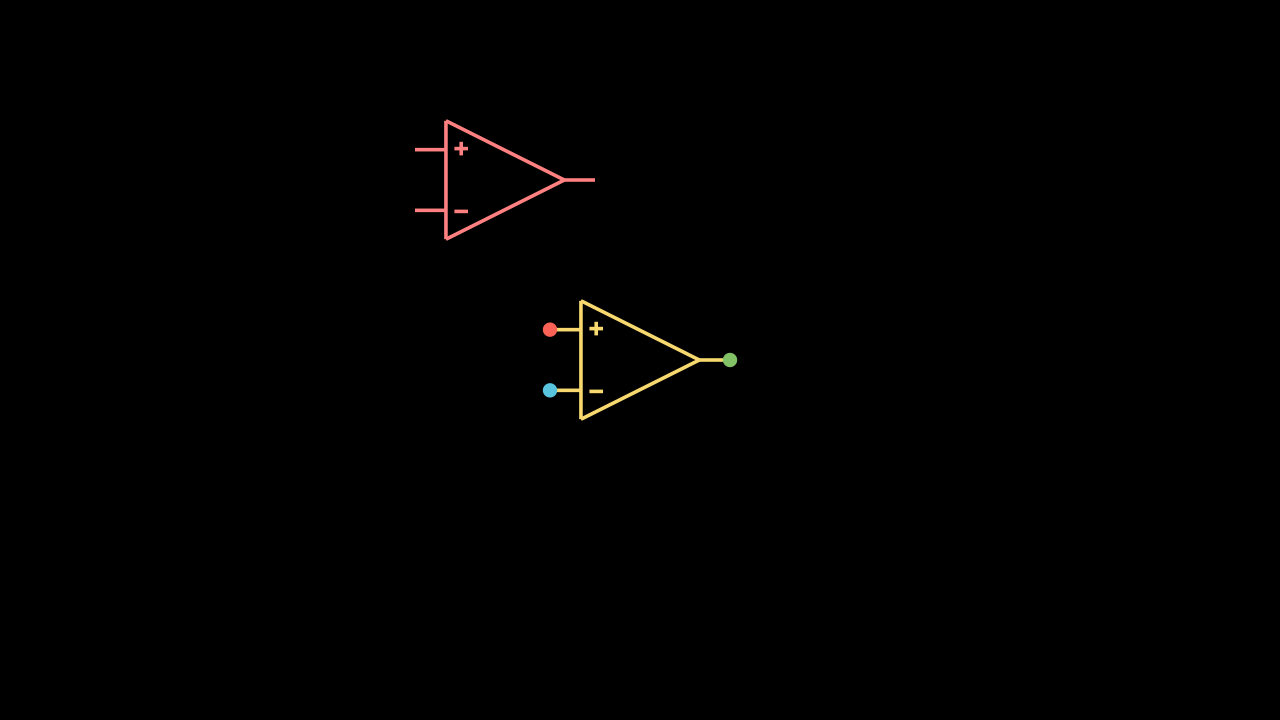

In [115]:
%%manim -qm OpampDemo

class OpampDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        shifted_op = Opamp(center=UP*2+LEFT*1.5, color=RED_B)
        self.add(
            op,
            shifted_op,
            Dot(op.get_conn_a().get_center(), color=RED),
            Dot(op.get_conn_b().get_center(), color=BLUE),
            Dot(op.get_conn_c().get_center(), color=GREEN)
        )

In [81]:
%%manim -qm OpampFlashDemo

class OpampFlashDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        flashDemo3(self, op)

Manim Community v0.20.1

In [82]:
%%manim -qm OpampRotateDemo

class OpampRotateDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        rotateDemo3(self, op)

Manim Community v0.20.1

In [83]:
%%manim -qm OpampScaleDemo

class OpampScaleDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        scaleDemo3(self, op)

Manim Community v0.20.1

In [84]:
%%manim -qm OpampShiftDemo

class OpampShiftDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        shiftDemo3(self, op)

Manim Community v0.20.1

## Potentiometer

In [116]:
class Potentiometer(Component3):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center

        # [RIGHT, UP]
        # Maybe find way to create a Resistor with 5 humps, then create an Arrow
        self.res_coords = [
            [0.0, 1.0], 
            [0.0, 0.5333333333333334], 
            [-0.10980392156862746, 0.4313725490196079], 
            [0.10980392156862746, 0.2901960784313726], 
            [-0.10980392156862746, 0.14901960784313728], 
            [0.10980392156862746, 0.0], 
            [-0.10980392156862746, -0.14901960784313728], 
            [0.10980392156862746, -0.2901960784313726], 
            [-0.10980392156862746, -0.4313725490196079], 
            [0.0, -0.5333333333333334], 
            [0.0, -1.0]
        ]

        self.arrow1_coords = [
            [0.225, -0.165],
            [0.10980392156862746, 0.0],
            [0.225, 0.165],
            [0.225, 0.0],
            [0.525, 0.0],
            [0.225, 0.0],
            [0.225, -0.165]
        ]

        self.arrow2_coords = [
            [0.325, -0.375],
            [0.25, -0.24],
            [0.175, -0.375],
            [0.25, -0.375],
            [0.25, -0.51],
            [0.25, -0.375],
            [0.325, -0.375]
        ]

        super().__init__(conn_a = UP*1.0, conn_b = DOWN*1.0, conn_c = RIGHT*0.525, center=self.mcenter, **kwargs)
    
    def generate_points(self):
        # Resistor section
        self.add_points(self.res_coords)
        # 1st Arrow section
        self.add_points(self.arrow1_coords)
        # 2nd Arrow section
        self.add_points(self.arrow2_coords)
    
    def add_points(self, coords):
        for i in (range(coords.__len__()-1)):
            self.add(Line(
                coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
            ))

Manim Community v0.20.1

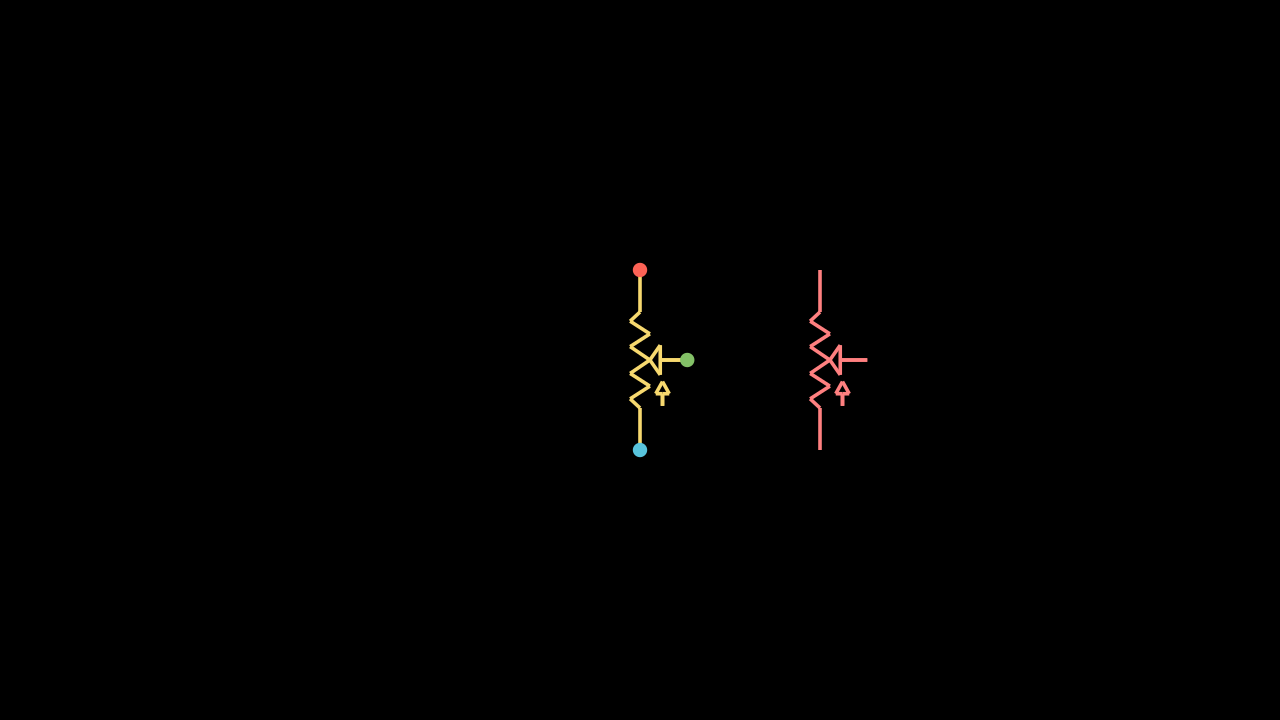

In [118]:
%%manim -qm PotentiometerDemo
class PotentiometerDemo(Scene):
    def construct(self):
        pot = Potentiometer(color=YELLOW)
        shifted_pot = Potentiometer(center=RIGHT*2, color=RED_B)
        self.add(
            pot,
            shifted_pot,
            Dot(pot.get_conn_a().get_center(), color=RED),
            Dot(pot.get_conn_b().get_center(), color=BLUE),
            Dot(pot.get_conn_c().get_center(), color=GREEN),
        )

In [119]:
%%manim -qm PotentiometerFlashDemo

class PotentiometerFlashDemo(Scene):
    def construct(self):
        pot = Potentiometer(color=YELLOW)
        flashDemo3(self, pot)

Manim Community v0.20.1

In [88]:
%%manim -qm PotentiometerRotateDemo

class PotentiometerRotateDemo(Scene):
    def construct(self):
        pot = Potentiometer(color=YELLOW)
        rotateDemo3(self, pot)

Manim Community v0.20.1

In [89]:
%%manim -qm PotentiometerScaleDemo

class PotentiometerScaleDemo(Scene):
    def construct(self):
        pot = Potentiometer(color=YELLOW)
        scaleDemo3(self, pot)

Manim Community v0.20.1

In [90]:
%%manim -qm PotentiometerShiftDemo

class PotentiometerShiftDemo(Scene):
    def construct(self):
        pot = Potentiometer(color=YELLOW)
        shiftDemo3(self, pot)

Manim Community v0.20.1

## 3-Way Switch

In [120]:
class Switch3(Component3):
    def __init__(self, center=ORIGIN, **kwargs):
        self.mcenter = center

        # [RIGHT, UP]
        self.left_bottom_coords = [
            [-0.5143, -0.2429],
            [-0.5143, -0.5714],
            [-1.071, -0.5714]
        ]

        self.left_top_coords = [
            [-0.5143, 0.2857],
            [-0.5143, 0.5071],
            [-1.071, 0.5071]
        ]

        self.right_coords = [
            [1.0, 0.0],
            [0.4286, 0.0],
            [-0.9214, -0.4571]
        ]

        self.bottom_connection = [
            [0.0, -0.1429],
            [0.0, -0.2857]
        ]

        self.bottom_squiggle = [
            [0.0, -0.3714],
            [0.0, -0.4857],
            [0.1571, -0.5714],
            [0.0, -0.65],
            [0.0, -0.8143]
        ]

        self.bottom_lines = [
            [0.0, -0.9714],
            [0.0, -1.307],
            [0.4214, -1.307],
            [-0.4214, -1.307]
        ]

        super().__init__(
            conn_a=self.left_bottom_coords[2][0]*RIGHT + self.left_bottom_coords[2][1]*UP,
            conn_b=self.left_top_coords[2][0]*RIGHT+self.left_top_coords[2][1]*UP,
            conn_c=self.right_coords[0][0]*RIGHT+self.right_coords[0][1]*UP,
            center=self.mcenter,
            **kwargs
        )

    def generate_points(self):
        self.add_points(
            self.right_coords,
            self.left_bottom_coords,
            self.left_top_coords,
            self.bottom_connection,
            self.bottom_squiggle,
            self.bottom_lines
        )
    
    def add_points(self, *coords_list):
        for coords in coords_list:
            for i in (range(coords.__len__()-1)):
                self.add(Line(
                    coords[i+1][0]*RIGHT+coords[i+1][1]*UP+self.mcenter,
                    coords[i][0]*RIGHT+coords[i][1]*UP+self.mcenter
                ))

Manim Community v0.20.1

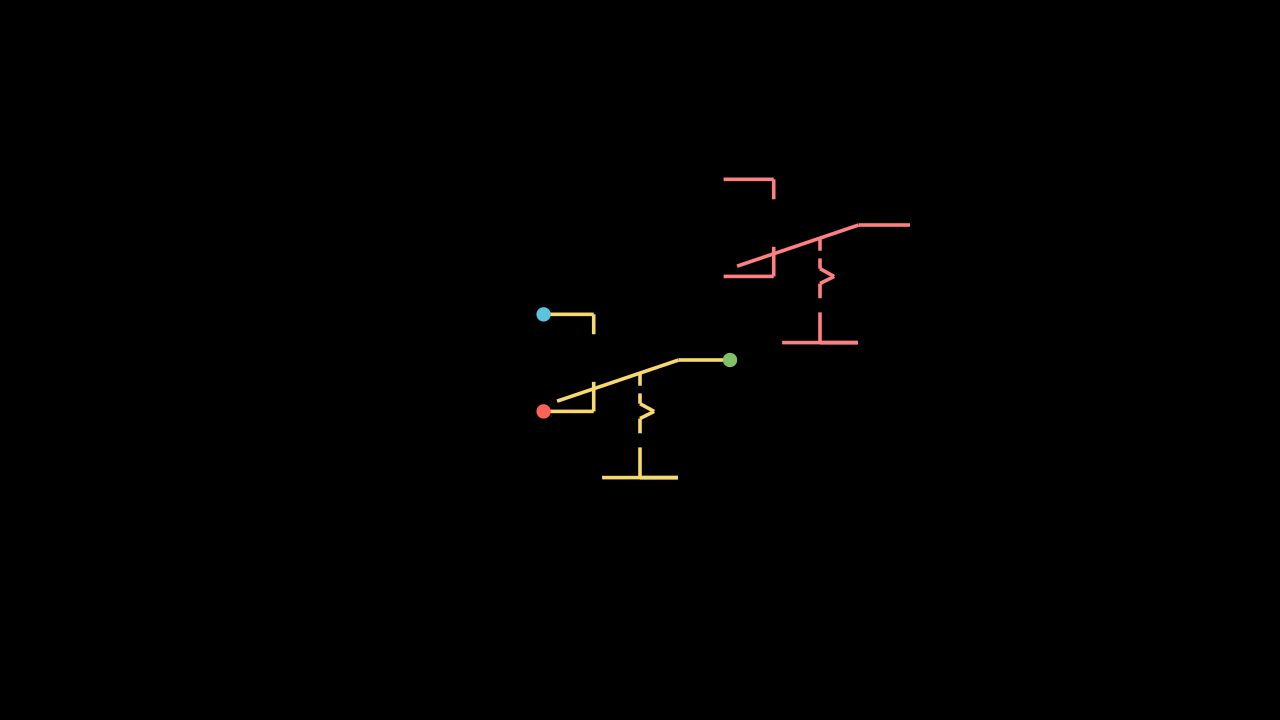

In [122]:
%%manim -qm Switch3Demo

class Switch3Demo(Scene):
    def construct(self):
        sw = Switch3(color=YELLOW)
        shifted_sw3 = Switch3(center=RIGHT*2+UP*1.5, color=RED_B)
        self.add(
            sw,
            shifted_sw3,
            Dot(sw.get_conn_a().get_center(), color=RED),
            Dot(sw.get_conn_b().get_center(), color=BLUE),
            Dot(sw.get_conn_c().get_center(), color=GREEN),
        )

In [93]:
%%manim -qm Switch3FlashDemo

class Switch3FlashDemo(Scene):
    def construct(self):
        sw = Switch3(color=YELLOW)
        flashDemo3(self, sw)

Manim Community v0.20.1

In [94]:
%%manim -qm Switch3RotateDemo

class Switch3RotateDemo(Scene):
    def construct(self):
        sw = Switch3(color=YELLOW)
        rotateDemo3(self, sw)

Manim Community v0.20.1

In [95]:
%%manim -qm Switch3ScaleDemo

class Switch3ScaleDemo(Scene):
    def construct(self):
        sw3 = Switch3(color=YELLOW)
        scaleDemo3(self, sw3)

Manim Community v0.20.1

In [96]:
%%manim -qm Switch3ShiftDemo

class Switch3ShiftDemo(Scene):
    def construct(self):
        sw3 = Switch3(color=YELLOW)
        shiftDemo3(self, sw3)

Manim Community v0.20.1

# Circuits

## Wires

In [97]:
class WireAttempt1(VMobject):
    def __init__(
            self,
            conn_a: Connection | Vector3D,
            conn_b: Connection | Vector3D,
            center = ORIGIN,
            **kwargs
    ) -> None:
        self.center = center

        if type(conn_a) == Vector3D:
            self.conn_a = conn_a
        elif type(conn_a) == Connection:
            self.conn_a = conn_a.get_center()

        if type(conn_b) == Vector3D:
            self.conn_b = conn_b
        elif type(conn_b) == Connection:
            self.conn_b = conn_b.get_center()

        self.coords = [self.conn_a, self.conn_b]

        '''
        if ((a*UP). == b*UP): # If UP is same
            self.coords.append(
                self.conn_a.get_center()*RIGHT+self.conn_a.get_center()*UP,
                self.conn_a.get_center()*RIGHT+self.conn_b.get_center()*UP
            )
        elif (a*RIGHT == b*RIGHT): # If RIGHT is same
            self.coords.append(
                self.conn_a.get_center()*RIGHT+self.conn_a.get_center()*UP,
                self.conn_b.get_center()*RIGHT+self.conn_a.get_center()*UP
            )
        else:
            self.coords.append(
                self.conn_a.get_center(),
                self.conn_b.get_center()
            )
        '''
            
        # Don't exist if both coordinates are the same

        # If Wire would go intersect through things

        super().__init__(**kwargs)

    def set_conn_a(self, conn_a):
        self.conn_a = conn_a
        self.coords[0] = conn_a
        return self
    
    def set_conn_b(self, conn_b):
        self.conn_b = conn_b
        self.coords[1] = conn_b
        return self
    
    
    def generate_points(self):
        self.start_new_path(self.center)
        self.set_points_as_corners(self.coords)

        

In [ ]:
class Wire(VGroup):
    def __init__(
        self,
        conn_a: Connection,
        conn_b: Connection,
        **kwargs
    ):
        super().__init__()

        # TODO: Possibly assign updaters according to the centers of conn_a and conn_b
        
        # Check if one or multiple lines necessary...
        # just check X/Y coords for now, should use PIP algorithm to avoid other circuit mobjects?

        right_val = (conn_a*RIGHT - conn_b*RIGHT)[0]
        up_val = (conn_a*UP - conn_b*UP)[1]

        right_check = abs(right_val) < 0.05
        up_check = abs(up_val) < 0.05
        
        # Use only one Line with both connections as endpoints IF either the X OR Y coords are the same
        if (right_check or up_check):
            self.add(Line(conn_a, conn_b, **kwargs))

        # TODO: Figure out prioritization of right and up coordinates, which one goes first...
        #       likely will have to consider "clockwise" or "counterclockwise" wire arrangement, if that makes sense 
        #       currently, the ground wire is messed up
        #
        #       For now, the a and b connections can be switched if it looks bad

        # Different X and Y coord requires 2 Lines
        # go to conn_b's x coord first
        elif right_val < 0 or up_val < 0:
            self.add(Line(conn_a, conn_b*UP+conn_a*RIGHT, **kwargs))
            self.add(Line(conn_b*UP+conn_a*RIGHT, conn_b, **kwargs))

        # go to conn_b's y coord first
        else:
            self.add(Line(conn_a, conn_b*RIGHT+conn_a*UP, **kwargs))
            self.add(Line(conn_b*RIGHT+conn_a*UP, conn_b, **kwargs))
            

Manim Community v0.20.1

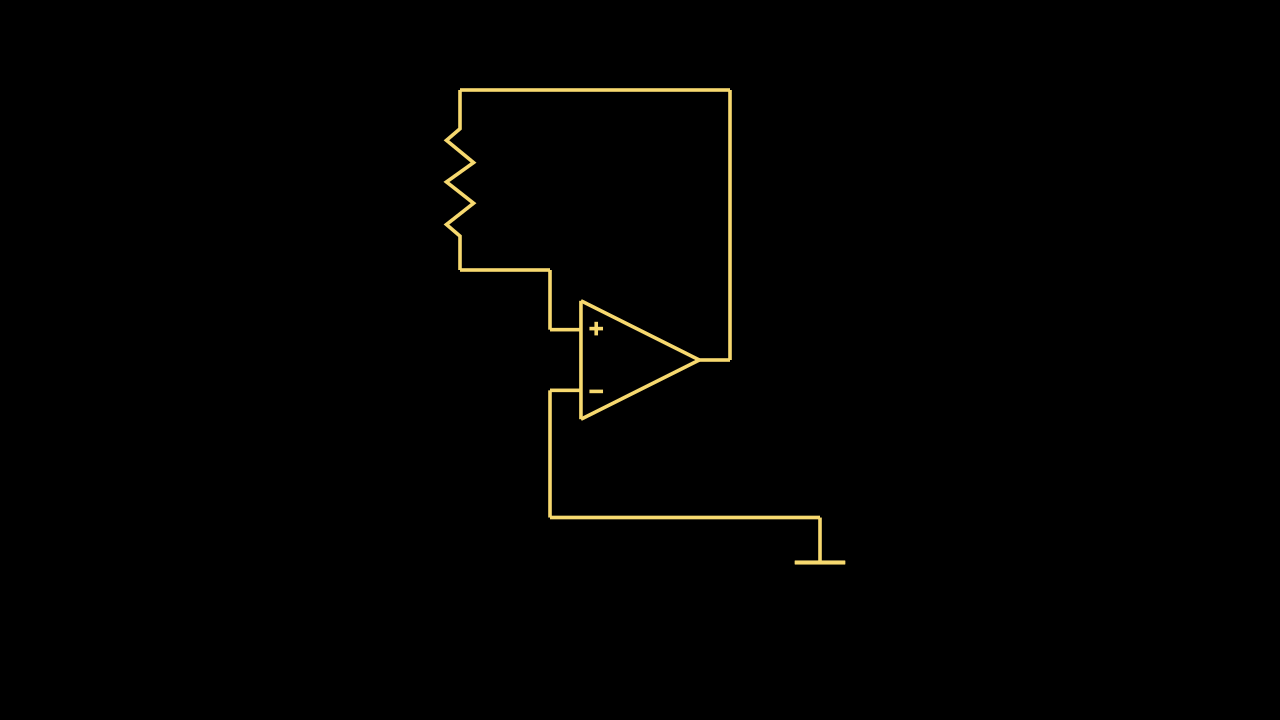

In [138]:
%%manim -qm wireDemo

class wireDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        connections = [op.get_conn_a(), op.get_conn_b(), op.get_conn_c()]
        feedback_resistor = Resistor(center=UP*2+LEFT*2, color=YELLOW).rotate(PI)

        ground = Ground(center=RIGHT*2+DOWN*2, color=YELLOW)

        wire1 = Wire(op.get_conn_a().get_center(), feedback_resistor.get_conn_a().get_center(), color=YELLOW)
        wire2 = Wire(op.get_conn_c().get_center(), feedback_resistor.get_conn_b().get_center(), color=YELLOW)
        wire3 = Wire(op.get_conn_b().get_center(), ground.get_conn().get_center(), color=YELLOW)

        self.add(
            op,
            feedback_resistor,
            ground,
            wire1,
            wire2,
            wire3
        )


In [139]:
%%manim -qm connectionDemo

class connectionDemo(Scene):
    def construct(self):
        op = Opamp(color=YELLOW)
        connections = [op.get_conn_a(), op.get_conn_b(), op.get_conn_c()]
        feedback_resistor = Resistor(color=YELLOW).rotate(PI/2)
        feedback_resistor.shift(UP*2)

        ground = Ground(color=YELLOW).shift(LEFT*2+DOWN)

        self.play(Create(op))
        self.wait()
        
        self.play(Create(feedback_resistor))
        self.wait()
        
        wire1 = Wire(op.get_conn_a().get_center(), feedback_resistor.get_conn_a().get_center(), color=YELLOW)
        wire2 = Wire(op.get_conn_c().get_center(), feedback_resistor.get_conn_b().get_center(), color=YELLOW)
        wire3 = Wire(ground.get_conn().get_center(), op.get_conn_b().get_center(), color=YELLOW)

        self.play(
            Create(wire1),
            Create(wire2)
        )
        self.wait()
        
        self.play(Create(ground))
        self.wait()

        self.play(Create(wire3))
        self.wait()

Manim Community v0.20.1

## Circuit Objects

In [ ]:
class Circuit(VGroup):
    def __init__(
        self,
        *components,
        **kwargs
    ):
        super().__init__()
        self.add(*components)
        

In [147]:
%%manim -qm wireDemo

class wireDemo(Scene):
    def construct(self):
        circ = Circuit()

        op = Opamp(color=YELLOW)
        connections = [op.get_conn_a(), op.get_conn_b(), op.get_conn_c()]
        feedback_resistor = Resistor(center=UP*2+LEFT*2, color=YELLOW).rotate(PI)

        ground = Ground(center=RIGHT*2+DOWN*2, color=YELLOW)

        wire1 = Wire(op.get_conn_a().get_center(), feedback_resistor.get_conn_a().get_center(), color=YELLOW)
        wire2 = Wire(op.get_conn_c().get_center(), feedback_resistor.get_conn_b().get_center(), color=YELLOW)
        wire3 = Wire(op.get_conn_b().get_center(), ground.get_conn().get_center(), color=YELLOW)

        circ.add(
            op,
            feedback_resistor,
            ground,
            wire1,
            wire2,
            wire3
        )

        self.play(Create(circ))

        self.play(circ.animate.shift(RIGHT))
        self.play(circ.animate.shift(LEFT))

        self.play(Uncreate(circ))


Manim Community v0.20.1